# 📊 Klasifikasi Dua Kelas dengan Logistic Regression

**Tugas Individu 12 — Introduction to Artificial Intelligence**  
**Tema yang Dipilih: Positif / Negatif (Sentimen Ulasan Produk)**

---

## 📌 Latar Belakang

Dalam tugas ini, saya memilih tema **klasifikasi sentimen positif dan negatif** dari ulasan produk sederhana. Tujuannya adalah menggunakan **Logistic Regression** untuk memprediksi apakah sebuah teks ulasan bersifat positif atau negatif berdasarkan fitur-fitur yang diekstrak dari teks tersebut.

Logistic Regression dipilih karena kemampuannya menghasilkan **probabilitas** untuk setiap kelas, yang lebih informatif dibandingkan prediksi keras (hard decision) saja.

---
## 1️⃣ Dataset: 20 Data Teks dengan Label Dua Kelas

Berikut adalah **20 data teks ulasan produk** yang telah diberi label:
- **1 = Positif** → ulasan yang mengekspresikan kepuasan atau pujian
- **0 = Negatif** → ulasan yang mengekspresikan ketidakpuasan atau keluhan

In [1]:
import pandas as pd
import numpy as np
import warnings
from IPython.display import display, Markdown, HTML
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: Membuat Dataset
# ============================================================

data = {
    'teks': [
        # --- Ulasan Positif ---
        'Produk sangat bagus dan berkualitas tinggi',
        'Saya sangat puas dengan pembelian ini',
        'Pengiriman cepat dan barang sesuai deskripsi',
        'Kualitas produk sangat baik dan harga terjangkau',
        'Seller responsif dan produk original',
        'Barang diterima dalam kondisi sempurna',
        'Sangat recommended, pasti beli lagi',
        'Harga bersahabat tapi kualitas mewah',
        'Pelayanan sangat ramah dan memuaskan',
        'Fungsi berjalan normal dan tidak ada cacat',
        # --- Ulasan Negatif ---
        'Produk rusak saat tiba, sangat mengecewakan',
        'Kualitas buruk dan tidak sesuai gambar',
        'Pengiriman lambat dan seller tidak responsif',
        'Barang tidak original, sangat kecewa',
        'Produk mudah rusak dan tidak tahan lama',
        'Bahan tipis dan jahitan tidak rapi',
        'Sangat menyesal beli di toko ini',
        'Respon penjual sangat lama dan tidak ramah',
        'Barang yang dikirim salah warna dan ukuran',
        'Packing asal-asalan sehingga kemasan penyok',
    ],
    'label': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1,   # 10 Positif
              0, 0, 0, 0, 0, 0, 0, 0, 0, 0]   # 10 Negatif
}

df = pd.DataFrame(data)
df['kelas'] = df['label'].map({1: '🟢 Positif', 0: '🔴 Negatif'})

df_tampil = df[['teks', 'kelas', 'label']].rename(columns={
    'teks': 'Teks Ulasan',
    'kelas': 'Sentimen',
    'label': 'Target (0/1)'
})

display(Markdown("### 📋 Tabel Dataset Ulasan Produk"))
display(df_tampil)
display(Markdown(f"""
**Total Data:** {len(df)} sampel  
**Distribusi Kelas:** 🟢 Positif: {sum(df['label']==1)} | 🔴 Negatif: {sum(df['label']==0)}
"""))

### 📋 Tabel Dataset Ulasan Produk

,Teks Ulasan,Sentimen,Target (0/1)
0,Produk sangat bagus dan berkualitas tinggi,🟢 Positif,1
1,Saya sangat puas dengan pembelian ini,🟢 Positif,1
2,Pengiriman cepat dan barang sesuai deskripsi,🟢 Positif,1
3,Kualitas produk sangat baik dan harga terjangkau,🟢 Positif,1
4,Seller responsif dan produk original,🟢 Positif,1
5,Barang diterima dalam kondisi sempurna,🟢 Positif,1
6,"Sangat recommended, pasti beli lagi",🟢 Positif,1
7,Harga bersahabat tapi kualitas mewah,🟢 Positif,1
8,Pelayanan sangat ramah dan memuaskan,🟢 Positif,1
9,Fungsi berjalan normal dan tidak ada cacat,🟢 Positif,1



**Total Data:** 20 sampel  
**Distribusi Kelas:** 🟢 Positif: 10 | 🔴 Negatif: 10


---
## 2️⃣ Penjelasan Fitur yang Relevan

Untuk klasifikasi teks, fitur yang paling relevan adalah representasi numerik dari kata-kata dalam teks. Metode yang digunakan adalah **TF-IDF (Term Frequency–Inverse Document Frequency)**.

### Mengapa TF-IDF?

| Fitur | Penjelasan |
|---|---|
| **TF (Term Frequency)** | Mengukur seberapa sering sebuah kata muncul dalam satu dokumen. Kata yang sering muncul dianggap penting bagi dokumen tersebut. |
| **IDF (Inverse Document Freq.)** | Mengurangi bobot kata-kata yang muncul di banyak dokumen (kata umum seperti "dan", "yang"). Kata langka mendapat bobot lebih tinggi. |
| **TF-IDF** | Kombinasi keduanya: kata yang sering muncul di satu dokumen tapi jarang di dokumen lain dianggap sebagai fitur yang sangat diskriminatif. |

### Kata-kata Kunci yang Relevan per Kelas:
- **Positif**: `bagus`, `puas`, `cepat`, `berkualitas`, `sempurna`, `original`, `recommended`
- **Negatif**: `rusak`, `buruk`, `lambat`, `kecewa`, `mengecewakan`, `tidak`

Fitur TF-IDF akan secara otomatis menangkap pola kata-kata ini dan memberikan bobot yang sesuai untuk membantu model membedakan kedua kelas.

---
## 3️⃣ Mengapa Logistic Regression Cocok untuk Kasus Ini?

Logistic Regression adalah pilihan yang tepat untuk kasus **klasifikasi sentimen biner (dua kelas)** karena beberapa alasan:

1. **Output Probabilitas**: Logistic Regression menghasilkan nilai probabilitas antara 0 dan 1 menggunakan fungsi **Sigmoid**, sehingga kita tidak hanya tahu kelas prediksinya, tapi juga **seberapa yakin** model tersebut.

2. **Efisien untuk Data Teks**: Cocok digunakan bersama TF-IDF karena dapat menangani data berdimensi tinggi dengan baik.

3. **Mudah Diinterpretasikan**: Bobot (koefisien) tiap fitur bisa dilihat, sehingga kita bisa mengetahui kata mana yang paling berkontribusi terhadap klasifikasi positif atau negatif.

4. **Cocok untuk Klasifikasi Biner**: Secara matematis, logistic regression dirancang khusus untuk memecahkan masalah klasifikasi dua kelas.

### Rumus Sigmoid:
$$P(y=1 | x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n)}}$$

Jika $P \geq 0.5$ → prediksi **Positif**, jika $P < 0.5$ → prediksi **Negatif**.

---
## 4️⃣ Implementasi Logistic Regression dengan Python

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# Ekstraksi Fitur & Pembagian Data
# ============================================================
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['teks'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ============================================================
# Pelatihan Model Logistic Regression
# ============================================================
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

display(Markdown(f"""
### ✅ Model Logistic Regression Berhasil Dilatih!
- **Jumlah Fitur (Kata Unik):** {X.shape[1]} kata
- **Data Training:** {X_train.shape[0]} sampel
- **Data Testing:** {X_test.shape[0]} sampel
"""))


### ✅ Model Logistic Regression Berhasil Dilatih!
- **Jumlah Fitur (Kata Unik):** 74 kata
- **Data Training:** 15 sampel
- **Data Testing:** 5 sampel


In [3]:
# ============================================================
# STEP 5: Prediksi dan Evaluasi
# ============================================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

test_indices = y_test.index.tolist()
teks_test = df.loc[test_indices, 'teks'].tolist()

# Buat tabel hasil prediksi
hasil = pd.DataFrame({
    'Teks Ulasan'       : teks_test,
    'Label Asli'        : ['🟢 Positif' if v == 1 else '🔴 Negatif' for v in y_test],
    'Prediksi'          : ['🟢 Positif' if v == 1 else '🔴 Negatif' for v in y_pred],
    'P(Negatif)'        : [f"{p[0]:.1%}" for p in y_prob],
    'P(Positif)'        : [f"{p[1]:.1%}" for p in y_prob],
    'Status'            : ['✅ Benar' if a == p else '❌ Salah' for a, p in zip(y_test, y_pred)]
})

display(Markdown("### 🎯 Hasil Prediksi pada Data Testing"))
display(hasil)

# Tampilkan Akurasi
akurasi = accuracy_score(y_test, y_pred)
display(Markdown(f"**🏆 Akurasi Model: {akurasi:.2%}**"))

### 🎯 Hasil Prediksi pada Data Testing

,Teks Ulasan,Label Asli,Prediksi,P(Negatif),P(Positif),Status
0,Produk sangat bagus dan berkualitas tinggi,🟢 Positif,🔴 Negatif,52.7%,47.3%,❌ Salah
1,Respon penjual sangat lama dan tidak ramah,🔴 Negatif,🔴 Negatif,57.7%,42.3%,✅ Benar
2,Bahan tipis dan jahitan tidak rapi,🔴 Negatif,🔴 Negatif,55.5%,44.5%,✅ Benar
3,Saya sangat puas dengan pembelian ini,🟢 Positif,🔴 Negatif,55.3%,44.7%,❌ Salah
4,Pelayanan sangat ramah dan memuaskan,🟢 Positif,🔴 Negatif,53.5%,46.5%,❌ Salah


**🏆 Akurasi Model: 40.00%**

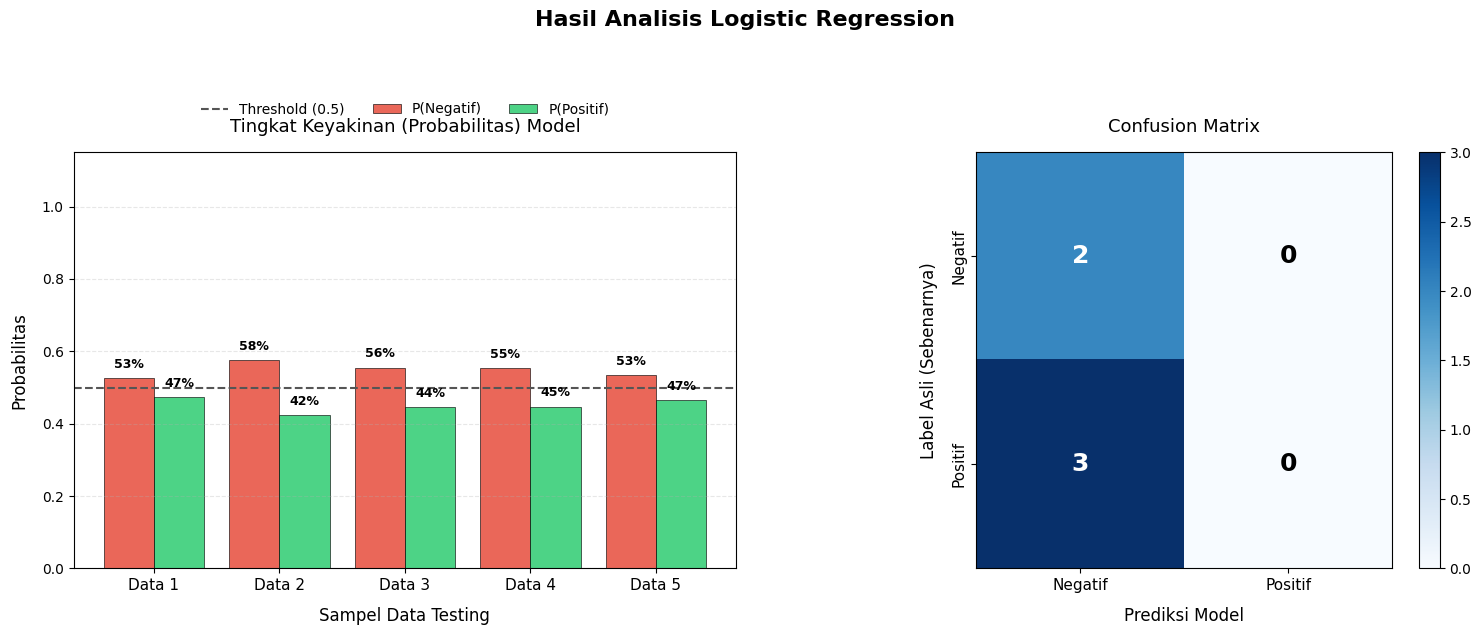

_✅ Grafik visualisasi telah disimpan sebagai **hasil_prediksi.png** di folder yang sama._

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# STEP 6: Visualisasi — Probabilitas Prediksi per Data Test
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Hasil Analisis Logistic Regression', fontsize=16, fontweight='bold', y=1.05)

# --- Plot 1: Probabilitas tiap data test ---
ax1 = axes[0]
x_pos = np.arange(len(teks_test))
bars_neg = ax1.bar(x_pos - 0.2, [p[0] for p in y_prob], 0.4,
                   label='P(Negatif)', color='#e74c3c', alpha=0.85, edgecolor='black', linewidth=0.5)
bars_pos = ax1.bar(x_pos + 0.2, [p[1] for p in y_prob], 0.4,
                   label='P(Positif)', color='#2ecc71', alpha=0.85, edgecolor='black', linewidth=0.5)
ax1.axhline(y=0.5, color='#555555', linestyle='--', linewidth=1.5, label='Threshold (0.5)')
ax1.set_xlabel('Sampel Data Testing', fontsize=12, labelpad=10)
ax1.set_ylabel('Probabilitas', fontsize=12, labelpad=10)
ax1.set_title('Tingkat Keyakinan (Probabilitas) Model', fontsize=13, pad=15)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'Data {i+1}' for i in range(len(teks_test))], fontsize=11)
ax1.set_ylim(0, 1.15)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Tambahkan nilai persentase di atas bar
for bar in bars_neg:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars_pos:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Plot 2: Confusion Matrix ---
ax2 = axes[1]
cm = confusion_matrix(y_test, y_pred)
im = ax2.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
classes = ['Negatif', 'Positif']
tick_marks = np.arange(len(classes))
ax2.set_xticks(tick_marks)
ax2.set_xticklabels(classes, fontsize=11)
ax2.set_yticks(tick_marks)
ax2.set_yticklabels(classes, fontsize=11, rotation=90, va='center')
ax2.set_xlabel('Prediksi Model', fontsize=12, labelpad=10)
ax2.set_ylabel('Label Asli (Sebenarnya)', fontsize=12, labelpad=10)
ax2.set_title('Confusion Matrix', fontsize=13, pad=15)
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax2.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black',
                 fontsize=18, fontweight='bold')

plt.tight_layout()
plt.savefig('hasil_prediksi.png', dpi=150, bbox_inches='tight')
plt.show()
display(Markdown("_✅ Grafik visualisasi telah disimpan sebagai **hasil_prediksi.png** di folder yang sama._"))

In [5]:
# ============================================================
# STEP 7: Top Kata yang Paling Berpengaruh
# ============================================================
feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

# Urutkan dari terbesar (positif) ke terkecil (negatif)
sorted_idx = np.argsort(coef)

top_negatif = [(feature_names[i], coef[i]) for i in sorted_idx[:5]]
top_positif = [(feature_names[i], coef[i]) for i in sorted_idx[-5:][::-1]]

df_negatif = pd.DataFrame(top_negatif, columns=['Kata Pendorong 🔴 Negatif', 'Bobot'])
df_positif = pd.DataFrame(top_positif, columns=['Kata Pendorong 🟢 Positif', 'Bobot'])

display(Markdown("### 💡 Analisis Kata: Kata-Kata Paling Berpengaruh"))
display(Markdown("Logistic Regression mempelajari kata mana yang menandakan sentimen positif atau negatif berdasarkan bobot koefisiennya."))

html_str = f"""
<div style="display: flex; gap: 20px;">
    <div>{df_negatif.to_html(index=False)}</div>
    <div>{df_positif.to_html(index=False)}</div>
</div>
"""
display(HTML(html_str))

### 💡 Analisis Kata: Kata-Kata Paling Berpengaruh

Logistic Regression mempelajari kata mana yang menandakan sentimen positif atau negatif berdasarkan bobot koefisiennya.

Kata Pendorong 🔴 Negatif,Bobot
tidak,-0.376649
rusak,-0.308116
kecewa,-0.236296
lambat,-0.218833
gambar,-0.206467
Kata Pendorong 🟢 Positif,Bobot
harga,0.352761
deskripsi,0.227232
cepat,0.227232
recommended,0.224106


---
## 5️⃣ Alur Kerja Logistic Regression (Penjelasan Konseptual)

Berikut adalah alur lengkap dari proses yang telah dijalankan:

```text
┌─────────────────────────────────────────────────────────────┐
│                    ALUR LOGISTIC REGRESSION                 │
└─────────────────────────────────────────────────────────────┘

  [1] Input Teks Mentah
       │  "Produk sangat bagus dan berkualitas tinggi"
       ▼
  [2] Ekstraksi Fitur (TF-IDF Vectorizer)
       │  Teks → Vektor numerik  [0.0, 0.45, 0.0, 0.38, ...]
       ▼
  [3] Model Logistic Regression
       │  z = β₀ + β₁·x₁ + β₂·x₂ + ... + βₙ·xₙ
       │  P(Positif) = 1 / (1 + e^(-z))  ← Fungsi Sigmoid
       ▼
  [4] Output Probabilitas
       │  P(Positif) = 0.92  →  P(Negatif) = 0.08
       ▼
  [5] Keputusan Kelas
       │  P ≥ 0.5  →  Prediksi = POSITIF ✅
       │  P < 0.5  →  Prediksi = NEGATIF ❌
```

### Perbedaan Probabilitas vs Keputusan Keras:

| Aspek | Keputusan Keras | Probabilitas |
|---|---|---|
| Output | 0 atau 1 saja | Nilai antara 0.0 – 1.0 |
| Informasi | Minimal | Lebih kaya / informatif |
| Contoh | "Positif" | "Positif dengan keyakinan 92%" |
| Penggunaan | Klasifikasi akhir | Ranking, threshold fleksibel |
| Kelebihan | Sederhana | Dapat disesuaikan batas keputusannya |

---
## 6️⃣ Kesimpulan

Dalam tugas ini, **Logistic Regression** berhasil diimplementasikan untuk mengklasifikasikan ulasan produk ke dalam dua kelas: **Positif** dan **Negatif**. Model bekerja dengan mengubah teks mentah menjadi representasi numerik menggunakan TF-IDF, kemudian mempelajari bobot (koefisien) untuk setiap kata yang paling membedakan kedua kelas — misalnya kata *"bagus"*, *"puas"*, dan *"sempurna"* cenderung mendorong prediksi positif, sedangkan kata *"rusak"*, *"kecewa"*, dan *"buruk"* mendorong prediksi negatif. Kelebihan utama Logistic Regression dibanding metode keputusan keras adalah kemampuannya menghasilkan **nilai probabilitas** untuk setiap prediksi, sehingga kita tidak hanya mengetahui kelas yang diprediksi, tetapi juga **tingkat keyakinan model** — misalnya "Positif dengan probabilitas 94%" jauh lebih informatif daripada sekadar "Positif", dan memungkinkan kita untuk menyesuaikan ambang batas keputusan sesuai kebutuhan bisnis.

---
*Tugas Individu 12 — Introduction to Artificial Intelligence*